In [2]:
# завдання: Розглянемо матрицю розміром 26 x 26, заповнену випадковим чином двійковими значеннями
# (комірка «мертва») або 1 (комірка «жива»). Наступне зображення представляє зразок, де зелені клітинки дорівнюють 1, а сірі – 0:
# Розробіть алгоритм, який приймає вказаний двійковий масив розміром 26x26 і повторює кроки, де кожен крок виконує такі правила: #Якщо жива клітина має двох або трьох живих сусідів, вона залишається живою; ● якщо жива клітина має одного чи жодного живого сусіда, вона гине від #"самотності";
# якщо жива клітина має чотирьох або більше живих сусідів, вона гине від «перенаселення»;
# якщо мертва клітина має рівно трьох живих сусідів, вона оживає.

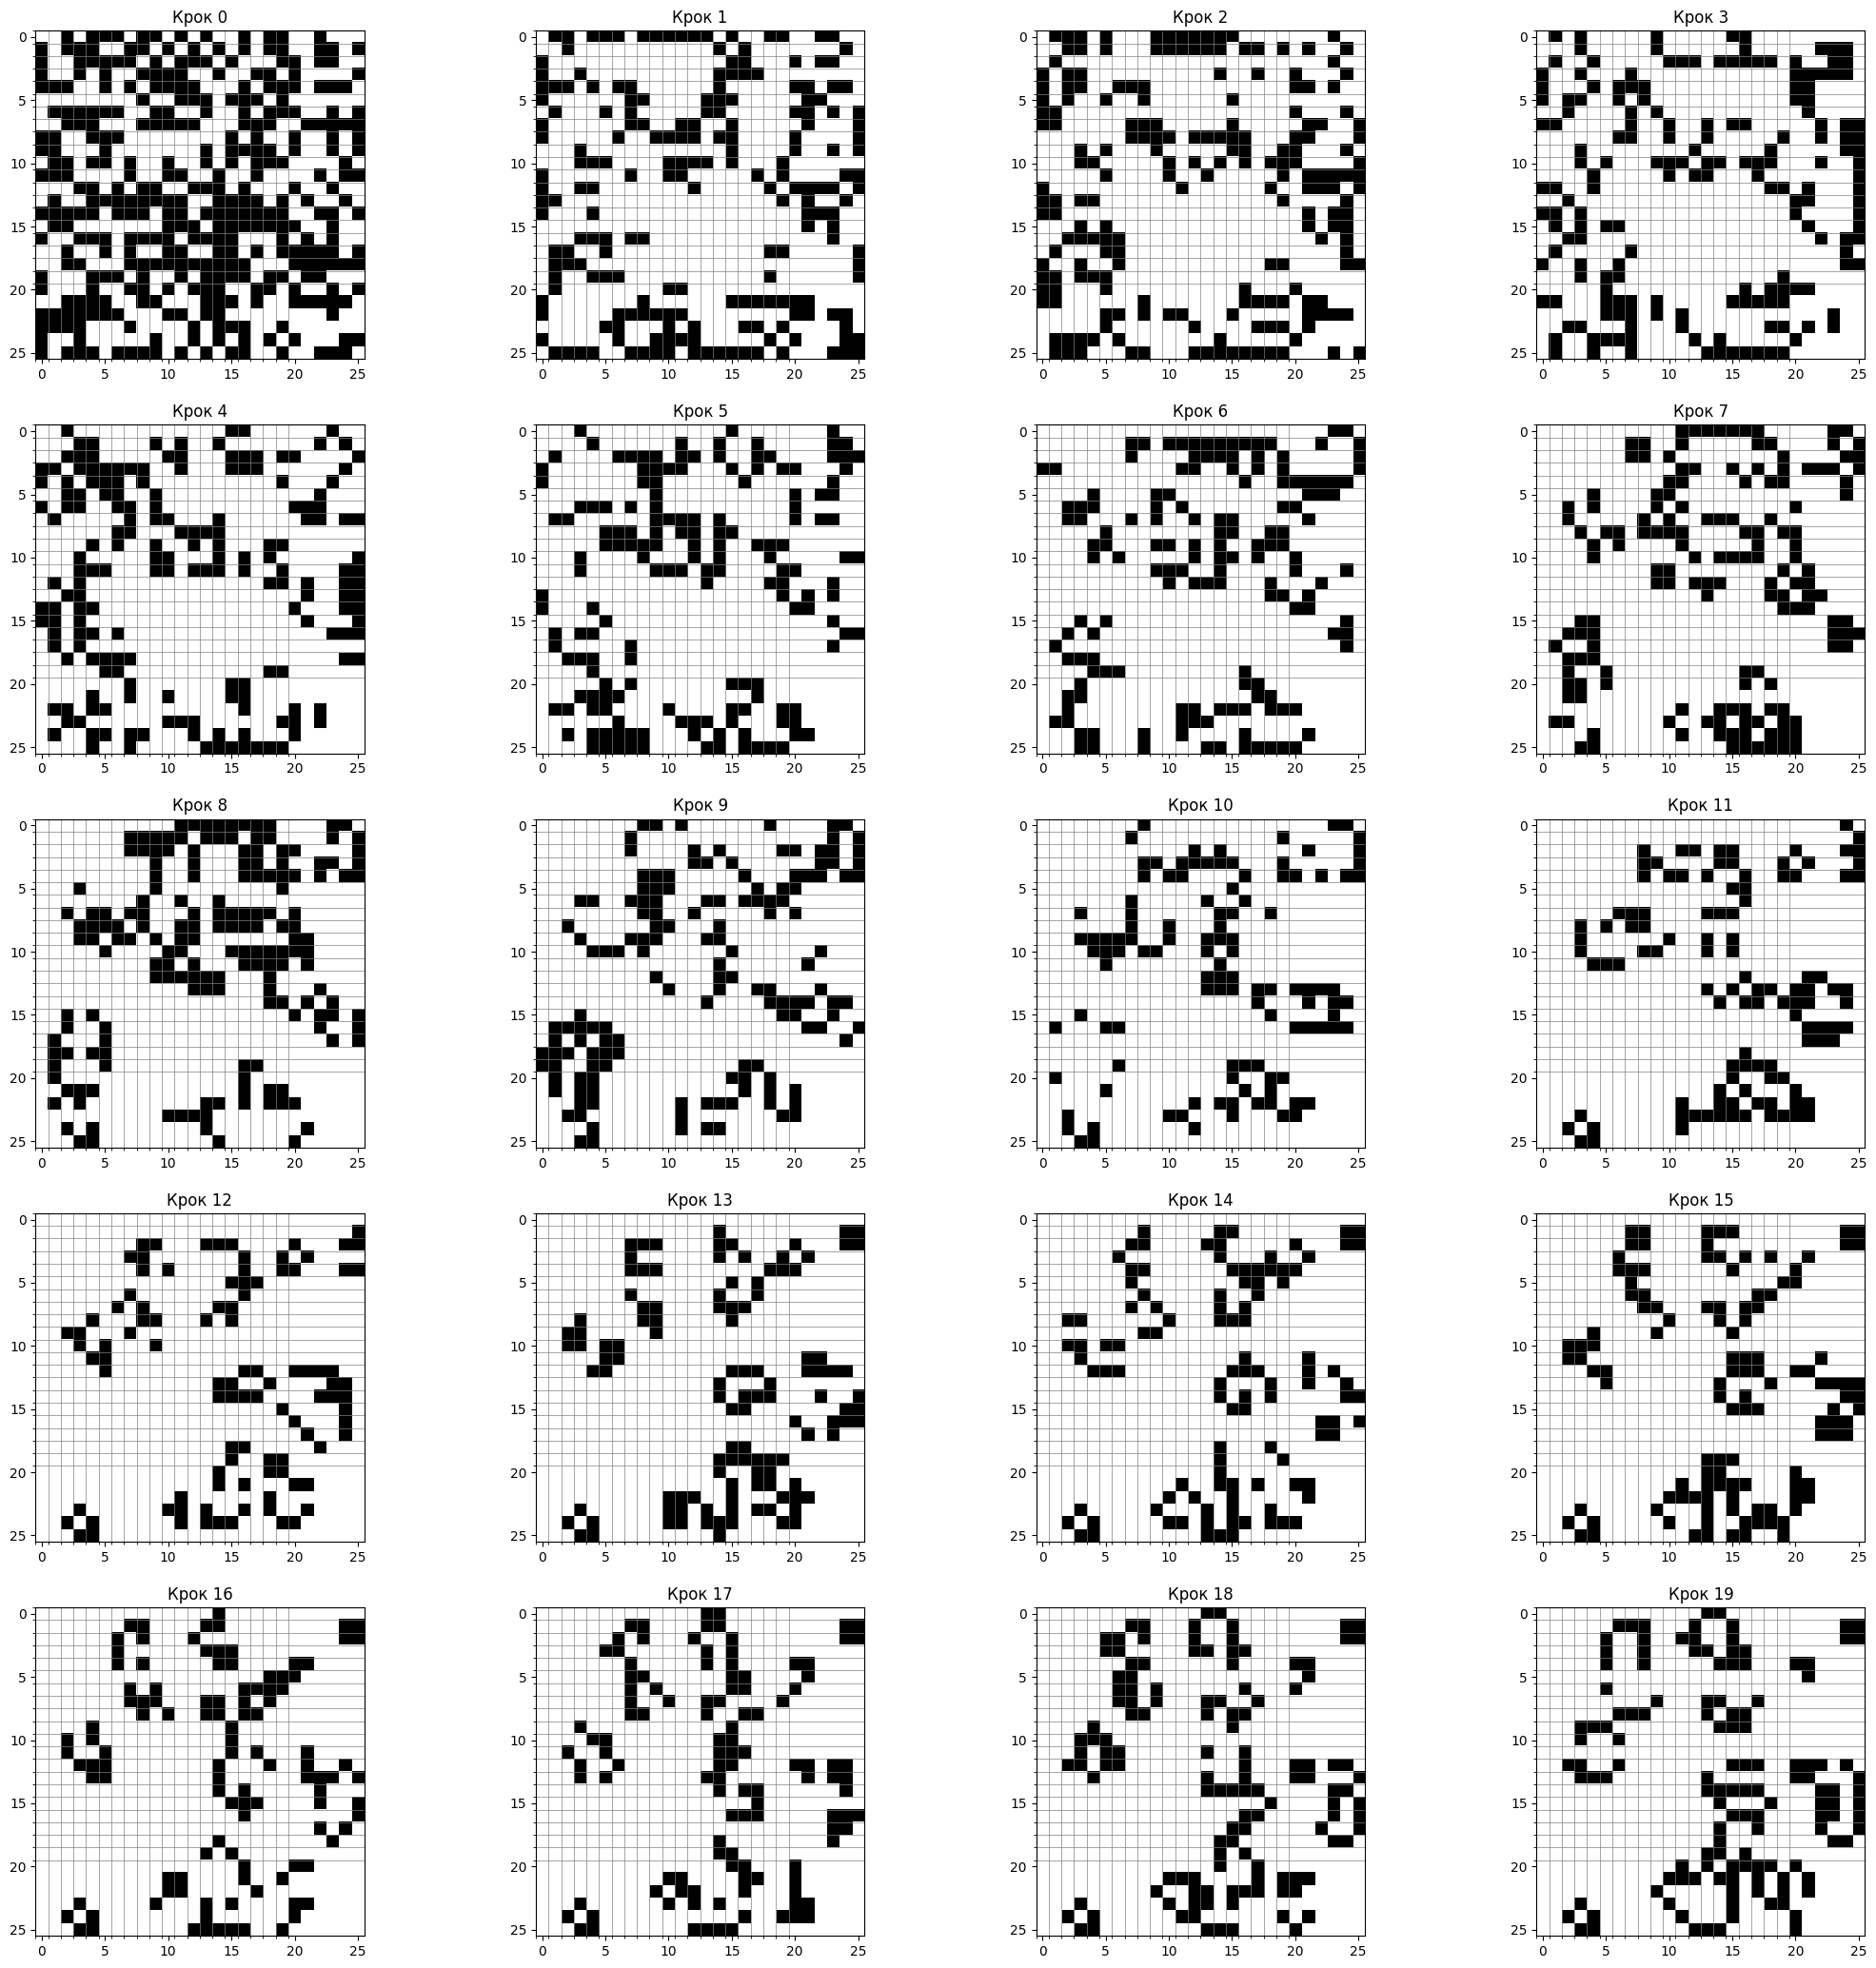

In [41]:
import numpy as np
import matplotlib.pyplot as plt
#grid змінна яка є нашим полем виживання
grid = np.random.randint(2 , size=(26, 26))
#функція для розрахунку еволюції клітинок
def get_next_step(current_grid):
    n_rows, n_cols = current_grid.shape #змінні для розмірів
    next_grid = np.zeros((n_rows, n_cols)) #створюється нове поле
    #вкладені цикли для перебору рядків та стовпчиків
    for r in range(n_rows):
        for c in range(n_cols):
            total_neighbors = np.sum(current_grid[max(0, r-1):min(r+2, n_rows), max(0, c-1):min(c+2, n_cols)]) - current_grid[r, c]
            if current_grid[r, c] == 1: #якщо клітинка жива
                if total_neighbors == 2 or total_neighbors == 3:
                    next_grid[r, c] = 1  #виживає
            else: # якщо клітинка мертва
                if total_neighbors == 3: 
                    next_grid[r, c] = 1 #оживає
    return next_grid
# малювалка для графіків, і з розташуванням
fig, axes = plt.subplots(5, 4, figsize=(26, 26))
axes = axes.flatten()
current_state = grid
for i in range(20): # цикл, який по черзі вибирає графіки і малює самі графіки
    # Поточний стан на відповідному підграфіку
    axes[i].imshow(current_state, cmap='binary')
    axes[i].set_title(f"Крок {i}")
    axes[i].set_xticks(np.arange(-0.5, 20, 1), minor=True)
    axes[i].set_yticks(np.arange(-0.5, 20, 1), minor=True) 
    axes[i].grid(which='minor', color='gray', linestyle='-', linewidth=0.5)
    current_state = get_next_step(current_state)
plt.show()